In [2]:
from IPython.display import Image

## 4. 신경망 이론 

### 1) 뉴런 (neuron) 

- 뉴런 neuron은 뇌의 정보처리 단위. 
  - 연산을 수행하는 세포체 (soma) 또는 cell body, 
  - 처리한 정보를 다른 뉴런에 전달하는 축삭 (axon), 
  - 다른 뉴런으로부터 정보를 받는 수상돌기 (dendrite)로 구성
- 사람 뇌는 1000억 ($10^{12}$)개 가량의 뉴런
   - 뉴런마다 1000개 가량 연결, 고도의 병렬 처리기
   - 2026년 기준 GPT4 GPT-4가 약 1.7조(1.7 Trillion)개로 사람의 수준을 넘어섬

### 2) 퍼셉트론 (Perceptron) 

- 사람의 뇌신경을 모방한 모델 (한계의 입-출력 계층만을 갖음)
- Frank Rosenblatt (1995)

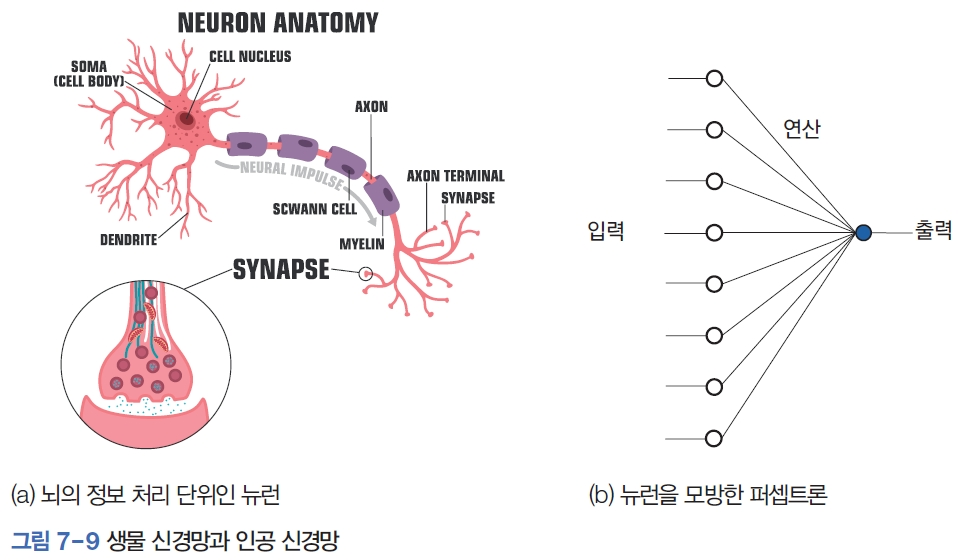

In [10]:
Image("그림 7-9.jpg", width=640)

### 퍼셉트론의 수식표현 
 
- 퍼셉트론 공식
    $o = \tau(s) = \tau( \sum_{i=0,d}  u_i x_i ) $
 
- $ u_i $ : 가중치,  $ W = (u_1, u_2, \cdots u_N)$: 가중치 벡터
- $ \tau(\cdot) $:  activation 함수 (비선형)
   - 특정 조건/패턴이 만족하는 입력이 있는지 (임게이치상 인지)를 알려주는 신호 
   - 이상적함수:    $\tau(s) = \begin{cases} 1 & s > 0 \\ -1(0) & s \leq 0 \end{cases}$  (미분이 불가능)
   - sigmoid 함수:  $\sigma(s) = \frac{1}{1 + e^{-s}}$
   - Relu 함수:     $f(s) = \max(0, s)$
   - tanh 함수:     $\tanh(s) = \frac{e^s - e^{-s}}{e^s + e^{-s}} = \frac{2}{1 + e^{-2s}} - 1$
                      
 
 

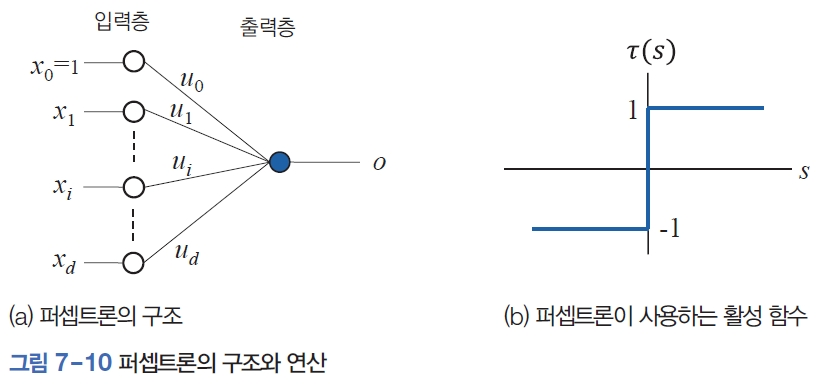

In [3]:
Image("그림 7-10.jpg", width=480)

#### 2) 동작 예시 (OR 연산)

- 입력 과 출력이 다음과 같은  동작을 하는 모델이 가능 (학습?)
 
 $$ (0,0) \rightarrow 0  \\ (0,1) \rightarrow 1  \\ (1,0) \rightarrow 1  \\  (1,1) \rightarrow 1 $$
 

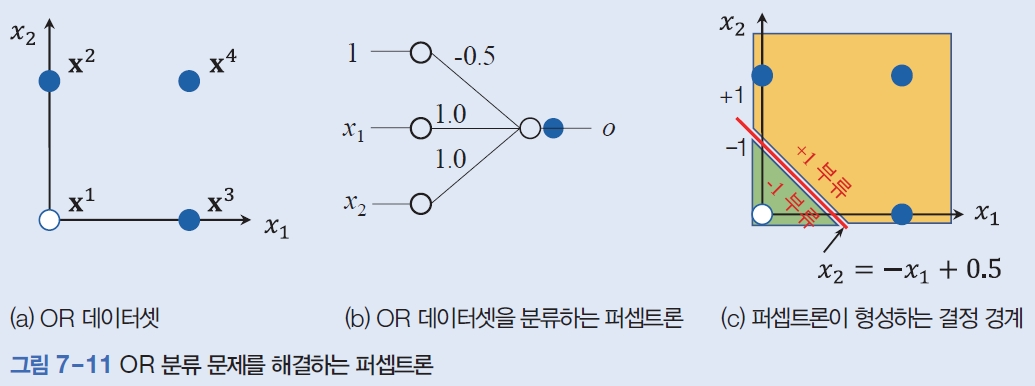

In [4]:
Image("그림 7-11.jpg", width=720)

#### 3) 비선형 문제에 도전:  분류 문제

- 오호! 컴퓨터의 연산을 다 만들어 낼수 있겠는데. 
  - CPU를 생각해보면 모든연산 (덧셈, 곱셈, 나아가 삼각함수 등등)은 NAND 나 NOR 게이트를 사용하여 만들수 있음. 
  - 더 나아가 비선형적인 문제도 풀수 있겠네.
  
- 일차적으로 가장 응용성이 높고 단순해 보이는 문제로 분류 문제를 사용함.
- 오 잘되는데!  자신감을 갖게됨.


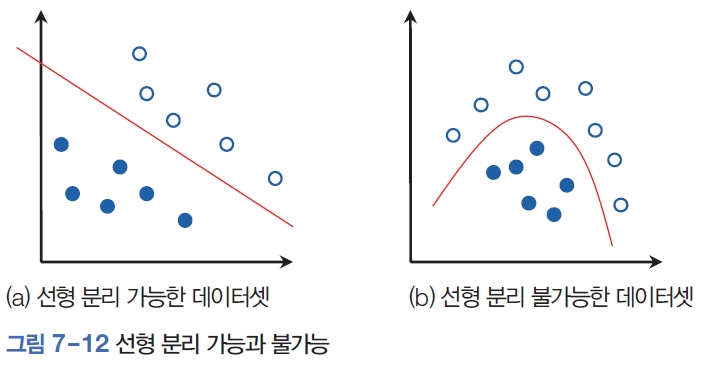

In [5]:
Image("그림 7-12.jpg", width=480)

### 4. 다층 퍼셉트론 

####   XOR 문제 (1차 난관)

- 이것도 풀수 있니? (Marvin Minsky가 제시)

 $$ (0,0) \rightarrow 0  \\ (0,1) \rightarrow 1  \\ (1,0) \rightarrow 1  \\  (1,1) \rightarrow 0 $$
 
- 1차 난관 : Perceptron (1계층 NN)으로는 풀수 없는 문제 

#### MLP (Multi Layer Perceptron)

- 다층 방식으로 해결 (Geoffrey Hinton가 해결)
- 이게 사실 이해가 안되는 것이, 이미 그당시 XOR는 논리회로 개발시 2단계로 만들어짐. 

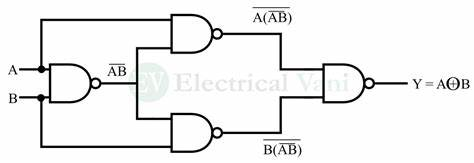

In [6]:
Image("xor.jpg", width=480)

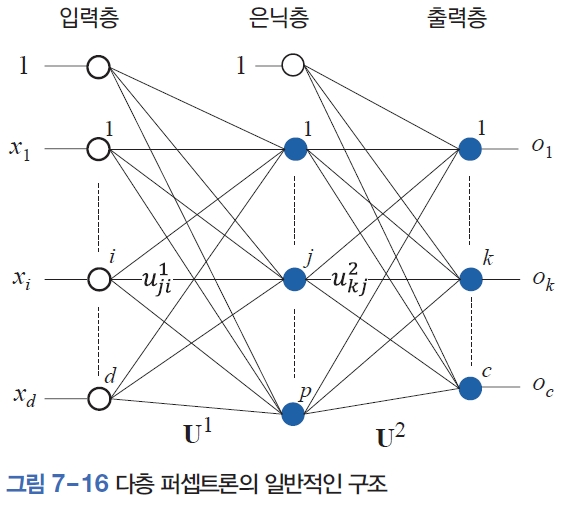

In [9]:
Image("그림 7-16.jpg", width=360)

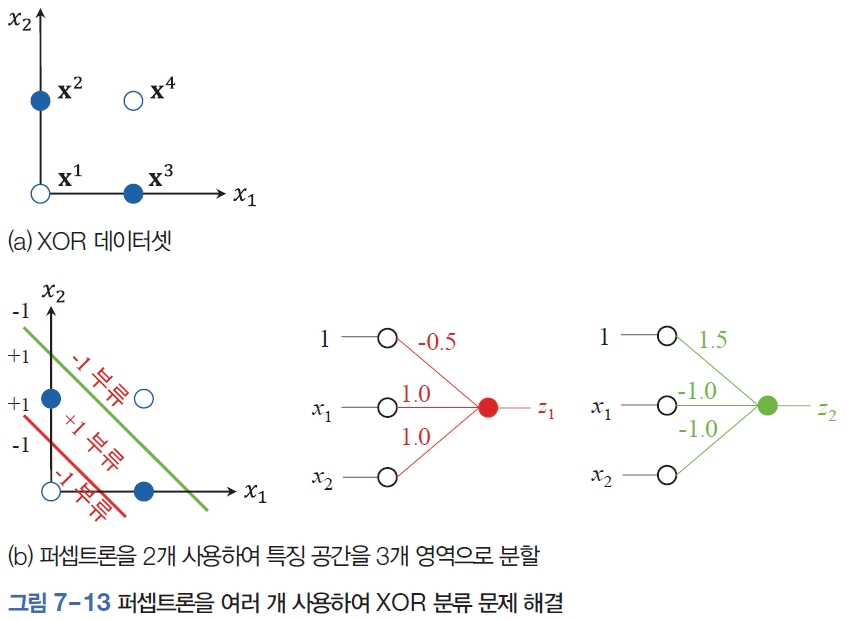

In [10]:
Image("그림 7-13.jpg", width=640)

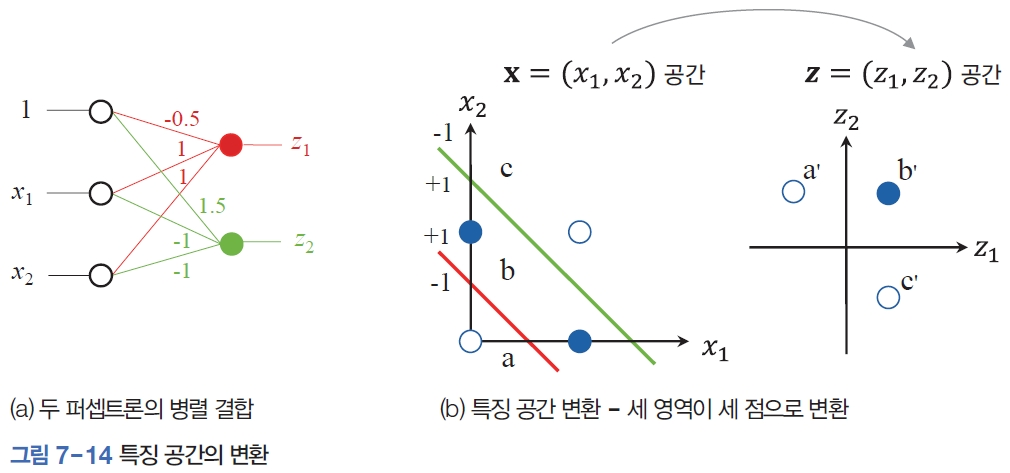

In [12]:
Image("그림 7-14.jpg", width=640)

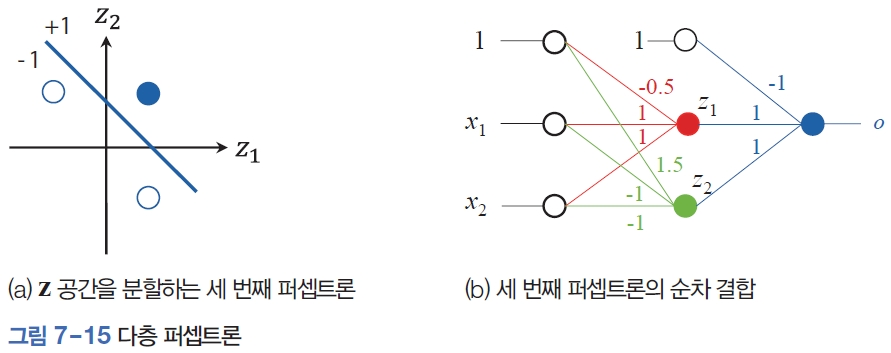

In [11]:
Image("그림 7-15.jpg", width=640)

### 신경망의 수학적 표현 

####  한계층의 연산
- 다음과 같이 벡터-행렬로 표현이 가능 
  (이 수식이 중요한 이유는 실제로 계산시에도 이러한 방식으로 구현이 된다는 것임)
    $$ y = \tau( U  x^T ) $$
 
 
  - $ x  = (1, x_1, x_2, \cdots, x_d ) $, $d$는 입력 차원, $1$은 bias를 위한 상수 
 
  - $ y  = (y_1, y_2, \cdots, y_p ) $, $p$는 출력력 차원
 
  - $ U $ 메트릭스는 px(d+1) 행렬
 $$ U = \begin{pmatrix}
u_{10} & u_{11} & \cdots & u_{1d} \\
u_{20} & u_{21} & \cdots & u_{2d} \\
\vdots & \vdots & \ddots & \vdots \\
u_{p0} & u_{p1} & \cdots & u_{pd}
\end{pmatrix} $$

####  다층의 연산

- 위의 과정을 반복 
- 예 3계층의 경우 (입력, 은익, 출력)
  $$ o = \tau( U_2  \tau( U_1   x^T ))$$
- $ h = \tau( U_1  x^T ), o = \tau( U_2  h^T ) $

## 6. 역전파이론 (Backpropagation)

- 다중 퍼셉트론을 사용했을때 각 계층의 파라메터를 조정하여 성능을 높이 (Loss 를 줄이는)는 밥법
   - Perceptron의 경우  "틀린 만큼 가중치를 직접 더하거나 빼는" Delta 방식이라는 것을 사용함. (복잡한 방식이 필요치 않앗고, activation에 step 함수를 사용하여 미분이 불가)
   
- 미적분학의 합성함수의 미분을 다루는 Chain-rule을 사용하여 적용함

   - 강의에서는 생략하나 매주 핵심 적인 부분이므로 시간되는대로 공부하기 바람.
   - https://youtu.be/Ilg3gGewQ5U?si=KiybiDmSWKGSQcv3




### 1) 학습 방법 (최적화) 

#### 경사 하강법  

- Loss (x) 함수 (입력 변수가 1개인 경우)가 최소가 되기 위해서는 수치적으로 다음과 같이 하면됨.

1) x에 대한 미분치가  + 이면, x가 작아지는 쪽으로 이동 
2) x에 대한 미분치가  - 이면, x가 커지는 쪽으로 이동.

이 를 반복하다가 더 이상 작아지지 않으면 중지함.(수학적으로 미분치가 0인 곳을 찾는 것과 동일)

- Newton이 개발 (수치적으로 함수의 해를 구하기 위하여)

- 다변수의 경우는 상미분을 편미분을 사용 하여 확장하면 됨
- 한계점: Local mininum 임.  

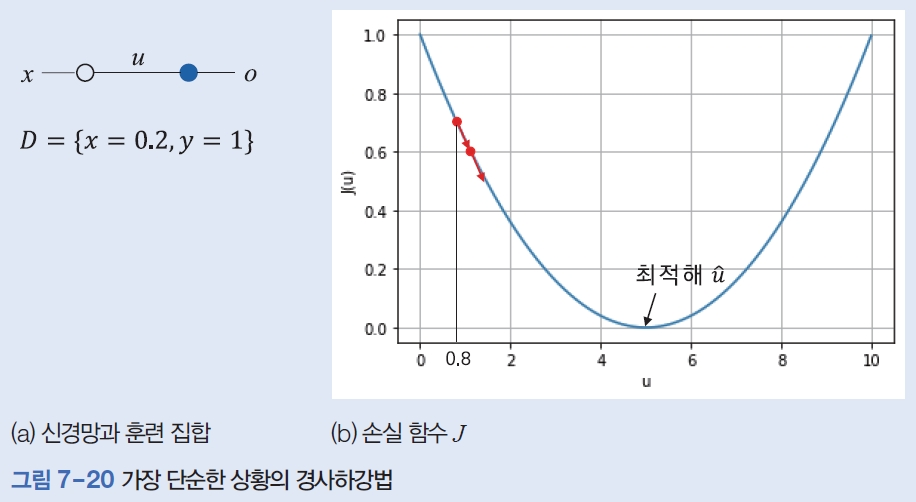

In [3]:
Image("그림 7-20.jpg", width=640)

#### 역전파에 적용  

- loss에서 시작하여 마지막 출력의 출력, 그리고 그 레이어의 입력(이전 레이어의 출력).... (Chain rule을 사용)
 
#####  Chain Rule (연쇄 법칙)

- 신경망은 여러 함수가 중첩된 합성함수
$$L = L(f(w \cdot x))$$ 
- **가중치 $w$** (입력이 아님!)를 조금 바꿨을 때, 손실 $L$은 얼마나 변하는가?
$$\frac{\partial L}{\partial w}$$
- 연쇄 법칙을 이용
$$\frac{\partial L}{\partial w} = \frac{\partial L}{\partial y} \cdot \frac{\partial y}{\partial w}$$
- 이를 각 레이어 별로 뒤로 가면서 단계적으로 적용하면 됨  

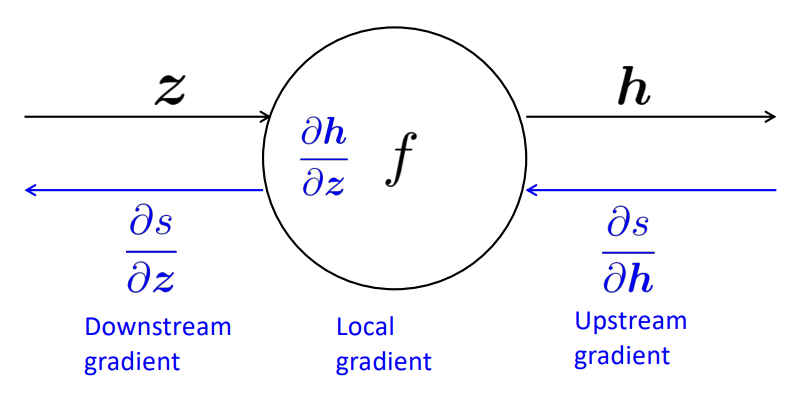

In [4]:
Image("backprop.png", width=480)

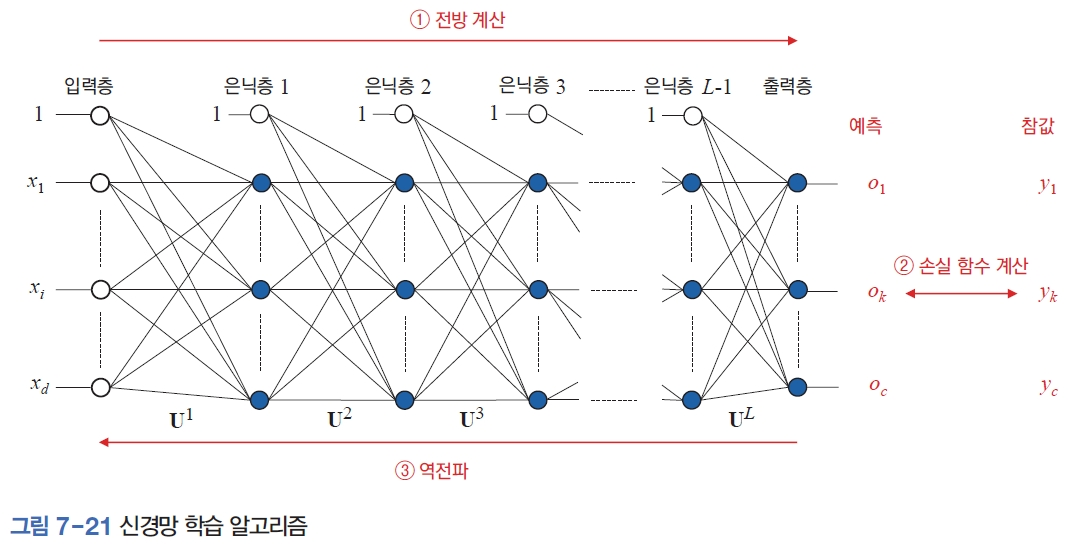

In [22]:
Image("그림 7-21.jpg", width=720)

#### 예 
- 간단한 선형 모델 $y = w \cdot x + b$와 손실 함수 $L = (y - y_{target})^2 $

#### 1. 전방계산 (forward pass)
 입력값 $x$를 넣어 예측값 $y$와 손실 $L$을 계산합니다.
  
#### 2. 후방계산 (backward pass: Gradient 계산)
- 먼저 손실에 대한 예측값의 미분을 구함
   $\frac{\partial L}{\partial y} = 2(y - y_{target})$
- 그 다음 예측값에 대한 가중치의 미분을 구함: 
   $\frac{\partial y}{\partial w} = x$
- 최종적으로 연쇄 법칙에 의해 가중치의 Gradient 구함: 
    $$\frac{\partial L}{\partial w} = 2(y - y_{target}) \cdot x$$
  
#### 3.  업데이트   
- 이 $\frac{\partial L}{\partial w}$  값을 이용해 가중치를 업데이트합니다 ($w = w - \eta \cdot \frac{\partial L}{\partial w}$, 여기서 $\eta$는 학습률). 

### 끝